# t-distributed stochastic neighbor embedding (t-SNE) with Python

Reference: https://www.geeksforgeeks.org/machine-learning/ml-t-distributed-stochastic-neighbor-embedding-t-sne-algorithm/

## Import Libraries

In [31]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits

## Download data

In [ ]:
# Load the small 8x8 digits dataset
digits = load_digits()

In [33]:
d = digits.data  
l = digits.target  

df = pd.DataFrame(d)
df['label'] = l  

X = df.drop('label', axis=1)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


## Visualize Data

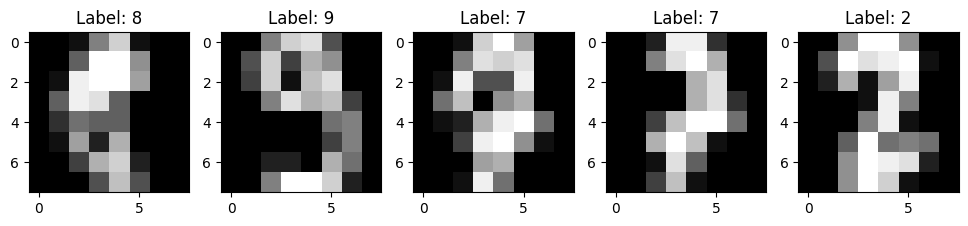

In [44]:
import random
random_indices = random.sample(range(len(df)), 5)
f, axes = plt.subplots(1, 5, figsize=(12, 4))
for i in range(5):
    axes[i].imshow(d[random_indices[i]].reshape(8, 8), cmap='gray')
    axes[i].set_title(f"Label: {l[random_indices[i]]}")

## (Optional) Scaler and Inverse Scaler

In [40]:
# standardized_data = StandardScaler().fit(X)

# scaler = StandardScaler()
# trans_data = scaler.fit_transform(X)
# print(trans_data[0:5,])

# org_data = scaler.inverse_transform(trans_data)
# print(org_data[0:5,])

## Creating clusters

In [63]:
model = TSNE(n_components = 2, random_state = 0)

tsne_data = model.fit_transform(X)
tsne_data

array([[ -2.9506352, -54.746494 ],
       [ 10.364837 ,  11.905801 ],
       [-14.046397 ,  18.980333 ],
       ...,
       [ -5.984237 ,  11.164667 ],
       [-21.077692 , -15.071691 ],
       [-14.146043 ,   7.260975 ]], shape=(1797, 2), dtype=float32)

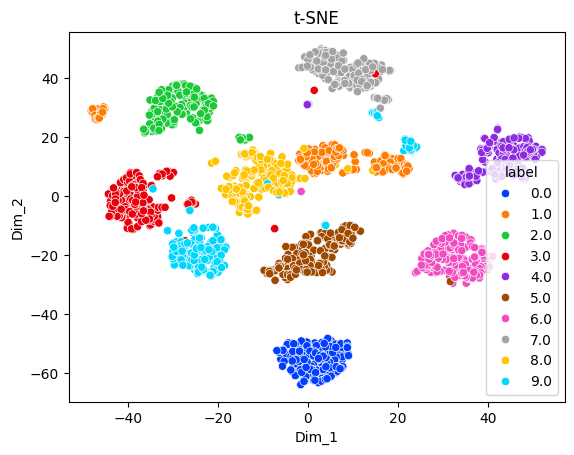

In [64]:
# Assigning the labels to the t-SNE data for visualization
tsne_data = np.vstack((tsne_data.T, l)).T
tsne_df = pd.DataFrame(data = tsne_data,
     columns =("Dim_1", "Dim_2", "label"))

sn.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2',
               hue='label', palette="bright")
plt.title("t-SNE")
plt.show()